In [1]:
import logging
from pathlib import Path
from datapackage import Package

from trails import (
    Trails,
    get_lcia_method_names,
    plot_temporal_scores,
    plot_rf,
    plot_temp,
    search_activity,
    clear_cache,
)
from trails.logging import configure_trails_logging

## 1. Load the Premise data package

Update the path below to your Premise export. The first run will build and cache
matrix interpolations; later runs reuse the cache. Use `clear_cache()` if you
change the package and want a clean rebuild.


In [2]:
# Optional: clear cache to force rebuild
# clear_cache()

configure_trails_logging(file_level=logging.INFO)

# Update to your Premise package path
premise_path = Path("/Users/romain/Library/CloudStorage/OneDrive-PaulScherrerInstitut/trails/data/trails_2026-03-02.zip")
package = Package(str(premise_path))

trails = Trails(
    package,
    interpolate_annual=True,
    debug=False,
    interpolation_start_year_offset=-20,
    interpolation_end_year_offset=20
)

Loading matrices from data package          [1/4]
Loading indices from data package           [2/4]
Interpolating matrices to annual resolution [3/4]
Building cache                              [4/4]
Data package cached at: /Users/romain/Library/Application Support/trails/cache/interp_7ab75159ebab


In [3]:
methods = [
    'IPCC 2021 - climate change: total (excl. biogenic CO2) - global warming potential (GWP100)',
    'IPCC 2021 (incl. biogenic CO2) - climate change: total (incl. biogenic CO2) - global warming potential (GWP100)',
]

In [4]:
# Example Excel inventory
filepaths = [
    #"lci-pass_cars.xlsx",
    "lci-case-study-daccs_storage_risk.xlsx",
    #"lci-case-study-fertilizer_n2o_timing.xlsx",
    #"lci-case-study-marine_fuel_switch.xlsx",
    #"lci-case-study-biomass_growth_vs_gas_heat.xlsx"
]

trails.import_excel_inventory(filepaths)

20:42:18+0100 [warning  ] Can't import `SimaProBlockCSVImporter` - please install `bw2io` with `pip install bw2io[multifunctional]` or install `multifunctional` and `bw_simapro_csv` manually.
Extracted 1 worksheets in 0.01 seconds
Applying strategy: csv_restore_tuples
Applying strategy: csv_restore_booleans
Applying strategy: csv_numerize
Applying strategy: csv_add_missing_exchanges_section
Applying strategy: normalize_units
Applying strategy: strip_biosphere_exc_locations
Applying strategy: set_code_by_activity_hash
Applying strategy: link_iterable_by_fields
Applying strategy: assign_only_product_as_production
Applying strategy: link_technosphere_by_activity_hash
Applying strategy: drop_falsey_uncertainty_fields_but_keep_zeros
Applying strategy: convert_uncertainty_types_to_integers
Applying strategy: convert_activity_parameters_to_list
Applied 13 strategies in 0.00 seconds
Imported Excel inventory: new_activities=1 matched_existing_activities=0 new_flows=0 matched_existing_flows=2 un

{'production': 1,
 'technosphere': 9,
 'biosphere': 2,
 'new_activities': 1,
 'new_flows': 0,
 'matched_existing_activities': 0,
 'matched_existing_flows': 2,
 'unlinked': 0,
 'replaced_A': 'rows',
 'replaced_B': 'rows',
 'scenario_indices': [100, 40, 30, 70, 80, 90, 60, 115, 20, 110, 50]}

In [5]:
trails.print_exchange_table(year=2020, act_idx=41792)

Temporal distribution codes:
+------+--------------------------------------+
| code |             distribution             |
+------+--------------------------------------+
|  1   |      discrete (all mass at loc)      |
|  2   |              lognormal               |
|  3   |                normal                |
|  4   |               uniform                |
|  5   |              triangular              |
|  6   | discrete empirical (explicit pulses) |
+------+--------------------------------------+
Temporal distribution fields:
+------------------------+---------------------------------------+
|         field          |                meaning                |
+------------------------+---------------------------------------+
| temporal_distribution  |           distribution code           |
|      temporal_loc      | location parameter (mean/median/mode) |
|     temporal_scale     |     scale parameter (stddev/sigma)    |
|      temporal_min      |   minimum integer offset (inclus

Temporal routing: 796672node [00:06, 124944.36node/s]
Temporal LCA: solve years: 100%|██████████████| 91/91 [01:46<00:00,  1.17s/year]


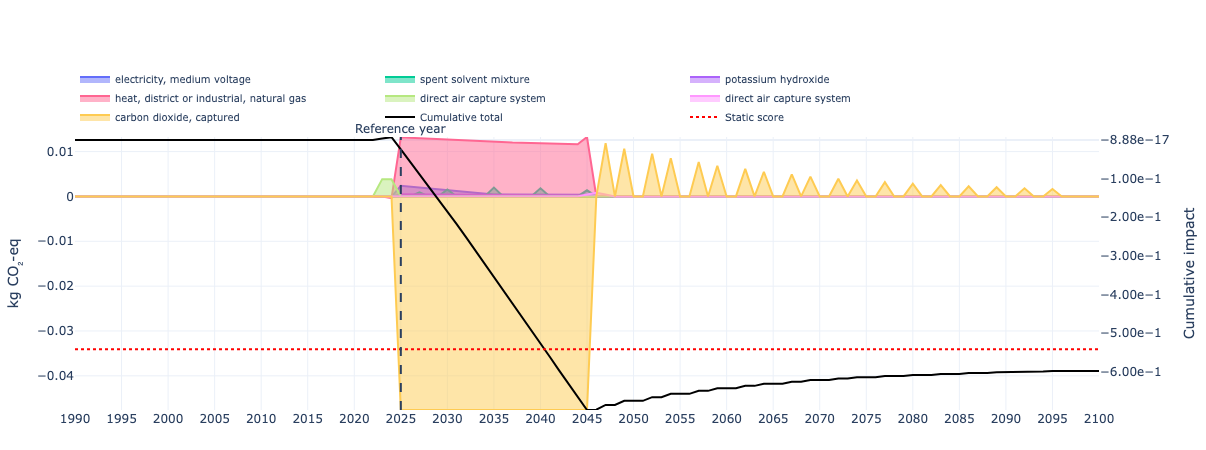

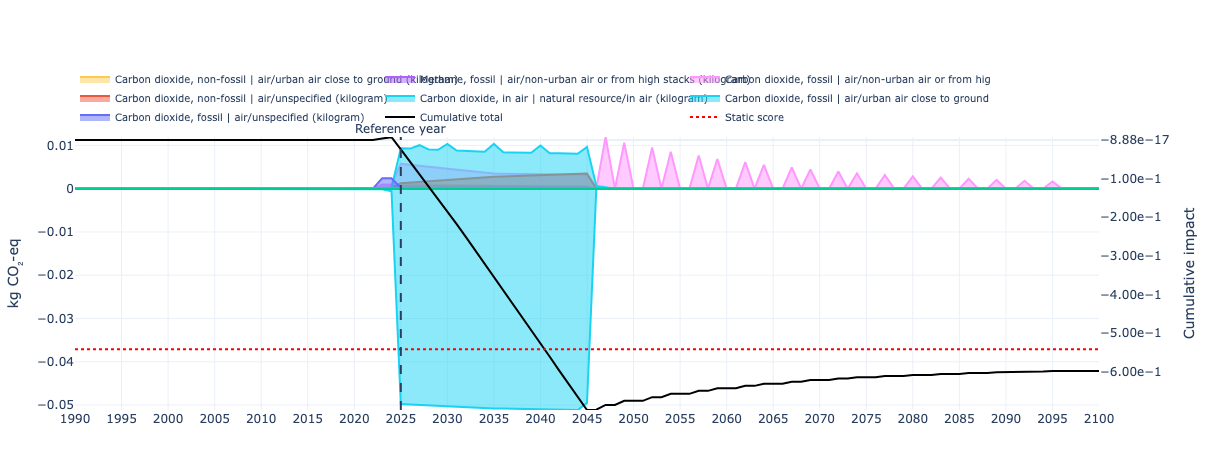

CPU times: user 2min 39s, sys: 28 s, total: 3min 7s
Wall time: 3min 19s


In [6]:
%%time

from trails.plotting import plot_temporal_graph

ref_year=2025

for idx in [
    #41792,
    #41793,
    #41794,
    #41800,
    #41801,
    41792
]:
    trails.temporal_routing(
        start_year=ref_year,
        start_act_idx=idx,
        amount=1,
        max_depth=4,
        show_progress=True,
        attribute_to_roots=True,
    )
    
    plot_temporal_graph(
        trails,
        filename=f"trails_graph_{idx}.html",
        notebook=False,
    )

    trails.lca(
        methods=methods,
        show_progress=True,
        compute_score=True,
        store_inventory=True,
        #solver_mode="direct",
        solver_mode="iterative",
        iterative_rtol=1e-3,
        #iterative_restart=100,
        #iterative_maxiter=2000,
    )


    trails.static_lca(
        year=ref_year,
        act_idx=idx,
        methods=methods,
    )
    
    static_score = trails.static_score

    figs = plot_temporal_scores(
        trails=trails,
        stacked=False,
        legend_top_n=7,
        show_flow_contributions=False,
        title="",
        method_label="kg CO₂-eq",
        cumulative=False,
        width=550,
        height=450,
        year_tick=5,
        year_range=(1990, 2100),
        reference_year=ref_year,
        show_cumulative_axis=True,
        static_score=static_score,
        static_score_dash="dot",
        static_score_color="red",
    )

    figs[1].show()

    figs = plot_temporal_scores(
        trails=trails,
        stacked=False,
        legend_top_n=7,
        show_flow_contributions=True,
        title="",
        method_label="kg CO₂-eq",
        cumulative=False,
        width=550,
        height=450,
        year_tick=5,
        year_range=(1990, 2100),
        reference_year=ref_year,
        show_cumulative_axis=True,
        static_score=static_score,
        static_score_dash="dot",
        static_score_color="red",
    )

    figs[1].show()

    
    

In [7]:
print(trails.scores.sum())

<xarray.DataArray ()> Size: 4B
array(-0.1975433, dtype=float32)


In [8]:
print(trails.scores.sum())

<xarray.DataArray ()> Size: 4B
array(-0.1975433, dtype=float32)


## 10. Climate emulator (FaIR)

We translate inventory time series into radiative forcing and temperature anomaly.
Results are stored as quantiles (2.5, 25, 50, 75, 97.5).


In [9]:
%%time
from trails.fair_rf import run_fair_delta_rf

rf = run_fair_delta_rf(
    trails,
    scenario="REMIND|SSP2-PkBudg650",
)

/opt/homebrew/Caskroom/miniforge/base/envs/trails/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html

FaIR per-species: 100%|████████████| 15/15 [01:10<00:00,  4.72s/run, HFC-32:pos]


CPU times: user 2min 10s, sys: 54.7 s, total: 3min 4s
Wall time: 2min 23s


### Plot radiative forcing and temperature


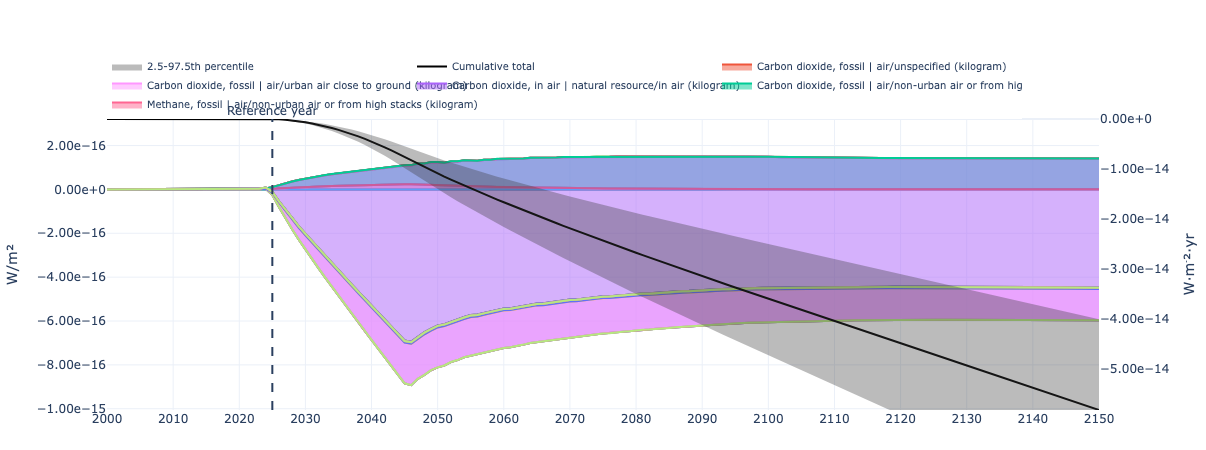

In [10]:
plot_rf(
    trails=trails,
    reference_year=ref_year,
    by="flow",
    year_range=(2000, 2150),
    year_tick=10,
)

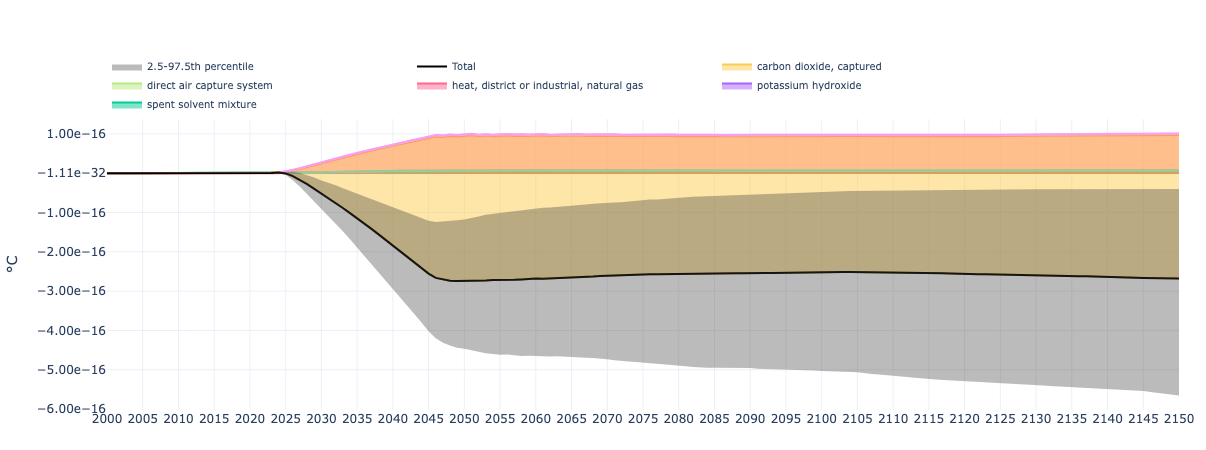

In [11]:
plot_temp(
    trails,
    by="root activity",
    title="Temperature change by root activity",
    method_label="°C",
    year_range=(2000, 2150),
)
